In [1]:
import os
from voxelwise_utils import *

/Users/shiochiba/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (None) doesn't match a supported version!
  warnings.warn(


/Users/shiochiba/voxelwise_tutorials_data/shortclips


In [2]:
DATA_DIR = "/Users/shiochiba/voxelwise_tutorials_data/shortclips"
os.makedirs(DATA_DIR, exist_ok=True)

print(DATA_DIR)

/Users/shiochiba/voxelwise_tutorials_data/shortclips


In [3]:
from voxelwise_tutorials.io import download_datalad

DATAFILES = [
    "features/wordnet.hdf",
    "mappers/S01_mappers.hdf",
    "responses/S01_responses.hdf",
]

source = "https://gin.g-node.org/gallantlab/shortclips"

for datafile in DATAFILES:
    path = download_datalad(datafile, destination=DATA_DIR, source=source)
    print("Downloaded:", path)

Downloaded: /Users/shiochiba/voxelwise_tutorials_data/shortclips/features/wordnet.hdf
Downloaded: /Users/shiochiba/voxelwise_tutorials_data/shortclips/mappers/S01_mappers.hdf
Downloaded: /Users/shiochiba/voxelwise_tutorials_data/shortclips/responses/S01_responses.hdf


In [4]:
#Load fmri
subject = "S01"
Y_train, Y_test, run_onsets = load_fmri_data(DATA_DIR, subject)

In [5]:
# cross validation
from voxelwise_tutorials.utils import generate_leave_one_run_out
cv = generate_leave_one_run_out(len(Y_train), run_onsets)

In [6]:
# Set backend
backend = set_default_backend()

/Users/shiochiba/miniconda3/lib/python3.13/site-packages/himalaya/backend/_utils.py:55: UserWarning: Setting backend to torch_cuda failed: PyTorch not installed..Falling back to numpy backend.
  warnings.warn(f"Setting backend to {backend} failed: {str(error)}."


In [7]:
# Load features
X_train, X_test = load_feature_space(os.path.join(DATA_DIR, 'features', 'wordnet.hdf'))

In [8]:
# Fit model
pipeline, scores = fit_kernel_ridge(
    X_train,
    X_test,
    Y_train,
    Y_test,
    cv
)

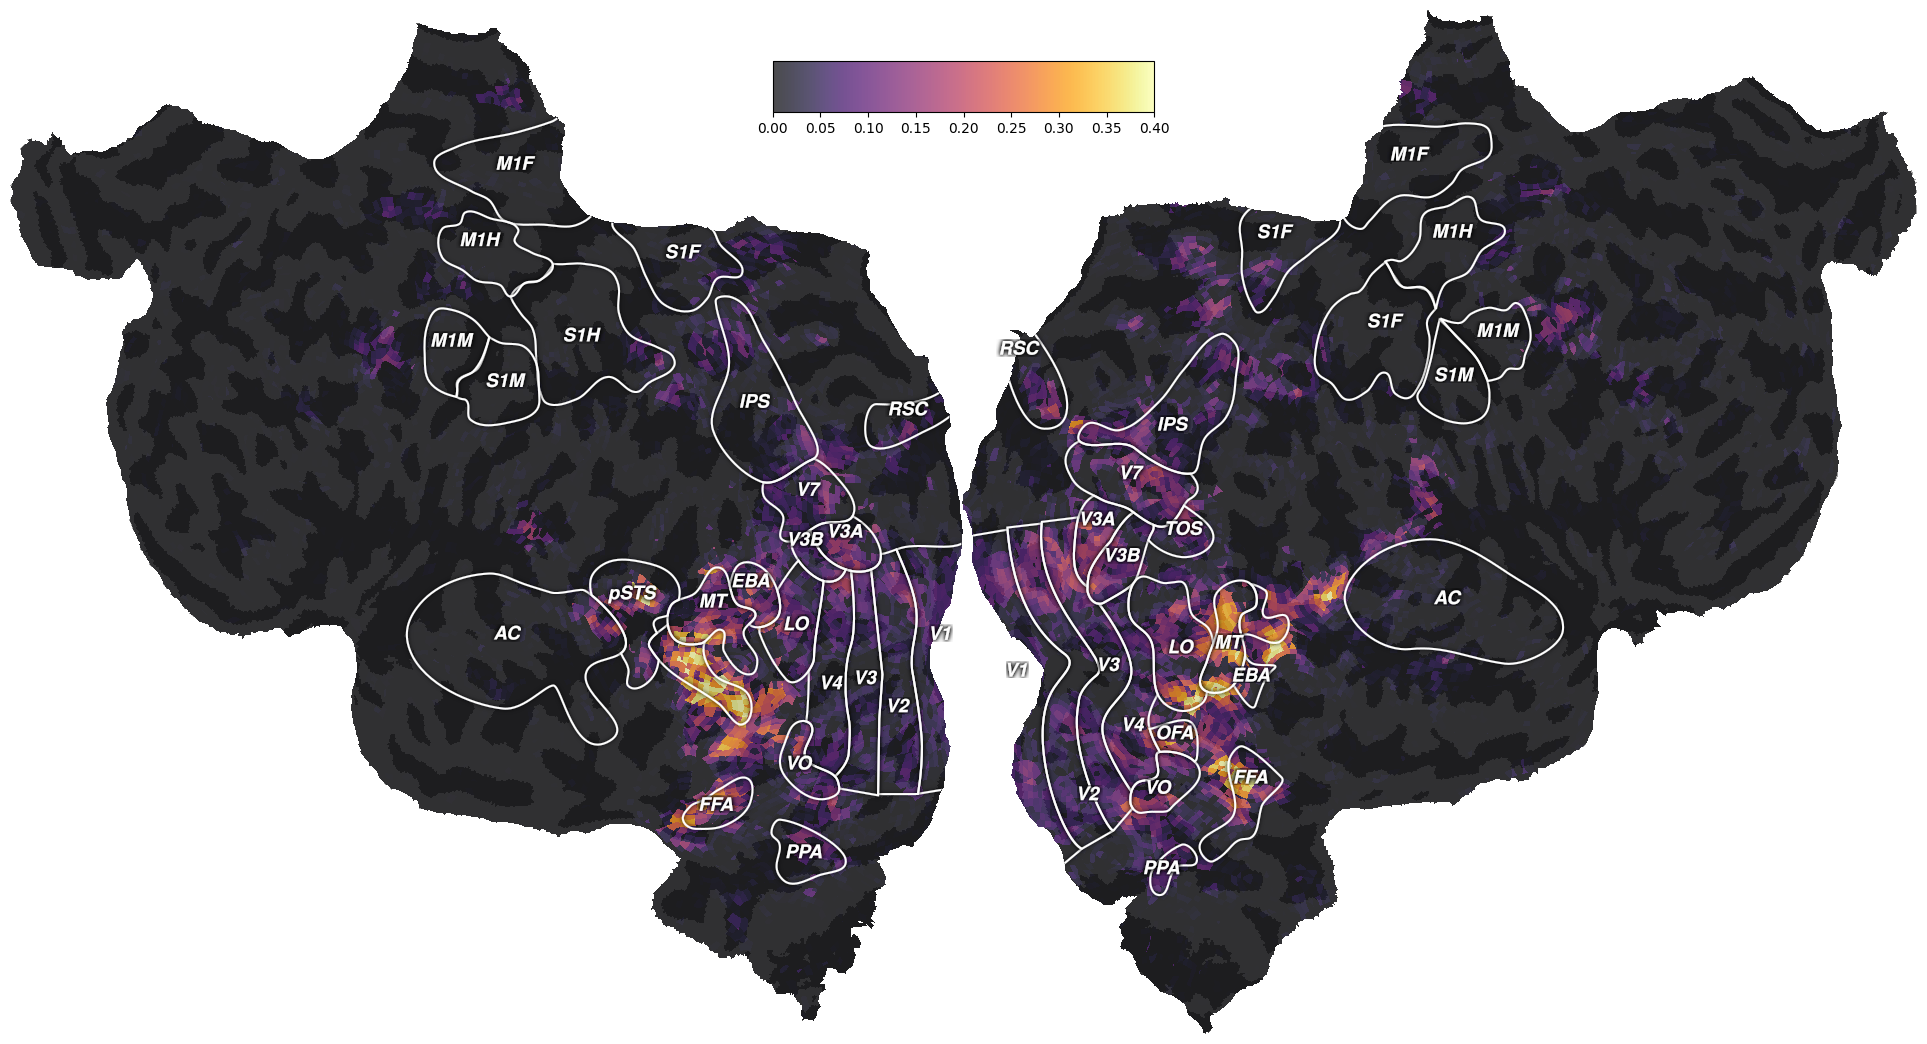

In [9]:
plot_single_model_flatmap(scores, subject="S01", directory=DATA_DIR)